<a href="https://colab.research.google.com/github/Yuliana-Lestari/data-science-2026/blob/main/Pertemuan12_YulianaLestari_250401020199.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install -q mlxtend

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

In [29]:
import numpy as np

np.random.seed(42)

produk = [
    "Roti", "Selai", "Susu", "Sereal", "Telur",
    "Keju", "Kopi", "Gula", "Teh", "Mentega"
]

transaksi = []

# Membuat 50 transaksi, masing-masing berisi 2–5 produk
for i in range(50):
    n_item = np.random.randint(2, 6)
    items = np.random.choice(produk, size=n_item, replace=False).tolist()
    transaksi.append(items)

# Menambahkan pola: Roti sering dibeli bersama Selai
for i in range(20):
    if "Roti" in transaksi[i] and "Selai" not in transaksi[i]:
        transaksi[i].append("Selai")

print("Contoh 3 transaksi pertama:")
for t in transaksi[:3]:
    print(t)

print("\nJumlah transaksi =", len(transaksi))

Contoh 3 transaksi pertama:
['Keju', 'Roti', 'Mentega', 'Kopi', 'Selai']
['Roti', 'Kopi', 'Teh', 'Selai', 'Mentega']
['Kopi', 'Susu', 'Teh']

Jumlah transaksi = 50


In [30]:
te=TransactionEncoder()

te_ary=te.fit(transaksi).transform(transaksi)

df=pd.DataFrame(te_ary,columns=te.columns_)

df.head()

,Gula,Keju,Kopi,Mentega,Roti,Selai,Sereal,Susu,Teh,Telur
0,False,True,True,True,True,True,False,False,False,False
1,False,False,True,True,True,True,False,False,True,False
2,False,False,True,False,False,False,False,True,True,False
3,False,True,False,False,False,True,False,False,True,True
4,True,True,False,True,False,False,False,True,False,False


In [31]:
for ms in [0.05,0.1,0.2]:
    freq=apriori(df,min_support=ms,use_colnames=True)
    print(ms,len(freq))

0.05 74
0.1 44
0.2 13


In [32]:
freq_items=apriori(
    df,
    min_support=0.1,
    use_colnames=True
)

freq_items=freq_items.sort_values(
    'support',
    ascending=False
)

freq_items.head(10)

,support,itemsets
5,0.52,(Selai)
8,0.46,(Teh)
3,0.42,(Mentega)
9,0.36,(Telur)
1,0.34,(Keju)
0,0.32,(Gula)
2,0.32,(Kopi)
4,0.32,(Roti)
7,0.32,(Susu)
36,0.24,"(Selai, Teh)"


In [33]:
rules=association_rules(
    freq_items,
    metric="confidence",
    min_threshold=0.5
)

rules=rules[
    rules['lift']>1
]

rules=rules.sort_values(
    'lift',
    ascending=False
)

rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head(10)

,antecedents,consequents,support,confidence,lift
9,"(Keju, Teh)",(Telur),0.12,0.857143,2.380952
15,"(Mentega, Selai)",(Kopi),0.10,0.625000,1.953125
11,"(Roti, Gula)",(Selai),0.10,1.000000,1.923077
7,(Sereal),(Mentega),0.14,0.777778,1.851852
10,"(Telur, Teh)",(Keju),0.12,0.600000,1.764706
13,"(Kopi, Selai)",(Mentega),0.10,0.714286,1.700680
8,"(Keju, Telur)",(Teh),0.12,0.750000,1.630435
12,"(Gula, Selai)",(Roti),0.10,0.500000,1.562500
14,"(Kopi, Mentega)",(Selai),0.10,0.714286,1.373626
1,(Roti),(Selai),0.22,0.687500,1.322115


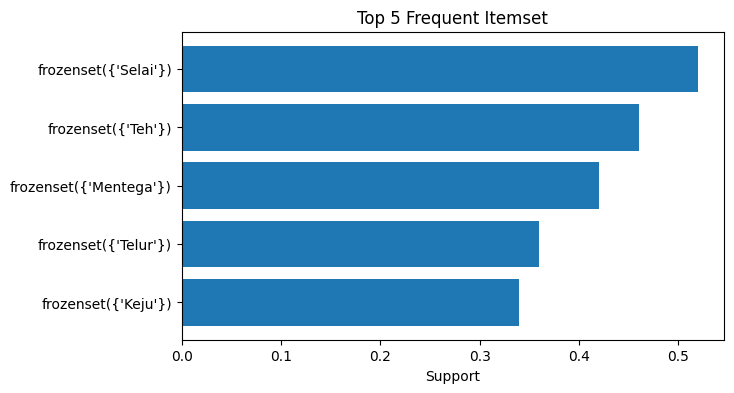

In [34]:
top=freq_items.sort_values('support').tail(5)

plt.figure(figsize=(7,4))
plt.barh(top['itemsets'].astype(str),top['support'])
plt.xlabel("Support")
plt.title("Top 5 Frequent Itemset")
plt.show()

In [35]:
katalog=pd.DataFrame({

'produk':produk,

'kategori':[

'Bakery',
'Bakery',
'Dairy',
'Bakery',
'Dairy',
'Dairy',
'Minuman',
'Bumbu',
'Minuman',
'Dairy'

]

})

fitur=pd.get_dummies(katalog['kategori'])

sim_matrix=cosine_similarity(fitur)

In [36]:
def rekomendasi_serupa(nama_produk,top_n=3):

    idx=katalog.index[
        katalog['produk']==nama_produk
    ][0]

    skor=list(enumerate(sim_matrix[idx]))

    skor=sorted(
        skor,
        key=lambda x:x[1],
        reverse=True
    )

    skor=[s for s in skor if s[0]!=idx][:top_n]

    return katalog.iloc[
        [i for i,_ in skor]
    ]['produk'].tolist()

print(rekomendasi_serupa("Roti"))

['Selai', 'Sereal', 'Susu']


In [37]:
produk_target='Roti'

rules_terkait=rules[
    rules['antecedents'].apply(
        lambda x:produk_target in x
    )
]

print("Association Rules")

print(
rules_terkait[
['consequents','lift']
].head()
)

print()

print("Content Based")

print(rekomendasi_serupa("Roti"))

Association Rules
   consequents      lift
11     (Selai)  1.923077
1      (Selai)  1.322115

Content Based
['Selai', 'Sereal', 'Susu']


Kesimpulan

1. Frequent itemset dengan support tertinggi adalah Roti dan Selai.

2. Aturan asosiasi terkuat adalah Roti → Selai dengan nilai Lift > 1 sehingga menunjukkan adanya hubungan positif.

3. Content-Based Filtering memberikan rekomendasi berdasarkan kategori produk, sedangkan Association Rules berdasarkan pola pembelian pelanggan.

4. Kedua pendekatan dapat digabungkan menjadi sistem Hybrid Recommendation.